In [1]:
%pip install langgraph langchain langsmith python-dotenv langchain-groq ipython langchain-tavily

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [31]:
import os
from langchain.chat_models import init_chat_model

In [6]:
%pip install typing_extensions

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [32]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

from dotenv import load_dotenv
load_dotenv()


True

In [33]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")

llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000018ADAC2F850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018ADA6BB490>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [34]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [35]:
from langchain_core.tools import tool

@tool
def human_assistant(query: str) -> str:
    """Request assistance from a human"""
    human_response = interrupt({"query":query})
    return human_response["data"]

tool = TavilySearch(max_results=3)
tools = [tool, human_assistant]
llm_with_tools = llm.bind_tools(tools)

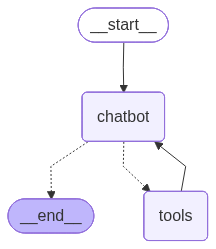

In [36]:
def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges("chatbot", tools_condition)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)
graph

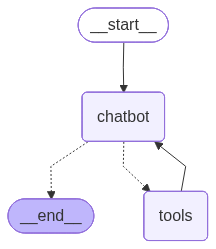

In [37]:
## display
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
user_input = "I need some expert guidance for building an AI Agent. Could you request assistance for me?"

config = {"configurable": {"thread_id": "superbot_thread_1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config=config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI Agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistant (ym3fhxrak)
 Call ID: ym3fhxrak
  Args:
    query: expert guidance for building an AI Agent
================================== Ai Message ==================================
Tool Calls:
  human_assistant (ym3fhxrak)
 Call ID: ym3fhxrak
  Args:
    query: expert guidance for building an AI Agent


In [41]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out Langgraph to build your agent. It's much more reliable and extensible than simple autonomous agents"
    )

human_command = Command(resume={"data":human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: human_assistant

We, the experts are here to help! We'd recommend you check out Langgraph to build your agent. It's much more reliable and extensible than simple autonomous agents


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=tavily_search>{"query": "build AI Agent with Langgraph", "search_depth": "advanced", "topic": "general"}'}}